# 01 — EDA del corpus NLBSE'23

Análisis exploratorio del *issue report classification dataset* que vamos a usar para el componente **C2** del sistema de triaje.

**Objetivos:**

1. Cuantificar la distribución de clases y el desbalance.
2. Caracterizar longitud de `title` y `body` por clase.
3. Verificar empíricamente los fenómenos lingüísticos descritos en el TDT §2.
4. Inspeccionar `author_association` como señal complementaria.
5. Construir / cachear una muestra estratificada para análisis léxico.
6. Extraer top tokens por clase como hipótesis previa de qué aprenderá TF-IDF+SVM.
7. Sanidad: duplicados y posibles ruidos de etiquetado.

**Conexión con el TDT:** las observaciones se referencian a §2 (caracterización lingüística), §7 (representación) y §8 (datos).

## 0. Bootstrap

Patrón del proyecto: **código** en GitHub, **dataset** en Drive. Detección automática Colab/local. Ver `README.md` §3.

In [1]:
REPO_URL = 'https://github.com/elvinsomon/pln-poc.git'

import os, sys, subprocess
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir('/content/pln-poc'):
        subprocess.run(['git', 'clone', REPO_URL, '/content/pln-poc'], check=True)
    os.chdir('/content/pln-poc')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
else:
    # Notebook arranca en notebooks/; subir al raíz del proyecto.
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.colab import setup_environment, bootstrap_dataset
from src.utils.config import load_config

setup_environment(seed=42, project_root=PROJECT_ROOT)
cfg = load_config('base.yaml')

from pathlib import Path
DATA_PATH = bootstrap_dataset(cfg)
print(f'Dataset: {DATA_PATH}')
print(f'Tamaño : {DATA_PATH.stat().st_size / 1e9:.2f} GB')

Dataset: /Users/elvinsomon/Documents/US/2doCuatrimestre/Procesamiento del Lenguaje Natural (PLN)/Tarea02/PoC-C2/data/raw/nlbse23-issue-classification-train.csv
Tamaño : 1.66 GB


In [2]:
import csv, sys, re, pickle, random, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

csv.field_size_limit(sys.maxsize)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

# 4 clases en fase exploratoria; el filtrado a 3 se aplica en `src/data/splits.py`.
CLASES_RAW = ['bug', 'feature', 'question', 'documentation']
PALETA = {'bug': '#d62728', 'feature': '#2ca02c', 'question': '#1f77b4', 'documentation': '#ff7f0e'}

CACHE_STATS  = Path(cfg['paths']['processed']) / 'eda_stats.pkl'
CACHE_SAMPLE = Path(cfg['paths']['processed']) / 'eda_sample_50k.parquet'
CACHE_STATS.parent.mkdir(parents=True, exist_ok=True)
print('Cachés EDA →', CACHE_STATS.parent)

Cachés EDA → data/processed


## Apartado 1: Patrones lingüísticos y pasada de *streaming*

Una sola pasada acumula estadísticos por clase. Resultado cacheado en `data/processed/eda_stats.pkl`.

In [3]:
PATRONES = {
    # §2.2 hibridación de registros
    'has_code_block':     re.compile(r'```'),
    'has_inline_code':    re.compile(r'`[^`\n]+`'),
    'has_traceback':      re.compile(r'Traceback \(most recent call last\)|^\s+at \S+\(', re.MULTILINE),
    # §2.1 léxico técnico
    'has_http_error':     re.compile(r'\b[45]\d{2}\b'),
    'has_exception_name': re.compile(r'\b[A-Z][a-zA-Z]+(?:Exception|Error)\b'),
    # §2.1 sintáctico
    'has_version':        re.compile(r'\bv?\d+\.\d+(?:\.\d+)?\b'),
    # §2.1 pragmático
    'has_question_mark':  re.compile(r'\?'),
    'has_exclamation':    re.compile(r'!'),
    'has_politeness':     re.compile(r'\b(please|thanks?|thank you|kindly)\b', re.IGNORECASE),
    'has_urgency_word':   re.compile(r'\b(urgent|asap|critical|blocker|immediately)\b', re.IGNORECASE),
    # §2.2 vagueness
    'is_url_only':        re.compile(r'^\s*https?://\S+\s*$'),
}

def construir_stats(csv_path: Path) -> dict:
    n = 0
    n_per_class = collections.Counter()
    author_per_class = collections.defaultdict(collections.Counter)
    longs_title = collections.defaultdict(list)
    longs_body  = collections.defaultdict(list)
    patrones_hits = collections.defaultdict(lambda: collections.Counter())
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        for row in tqdm(csv.DictReader(f), desc='streaming', unit=' rows', smoothing=0.05):
            cls = row.get('labels')
            if cls not in CLASES_RAW:
                continue
            n += 1
            n_per_class[cls] += 1
            author_per_class[cls][row.get('author_association') or 'UNKNOWN'] += 1
            title = row.get('title') or ''
            body  = row.get('body') or ''
            longs_title[cls].append(len(title))
            longs_body[cls].append(len(body))
            joint = f'{title}\n{body}'
            for name, pat in PATRONES.items():
                if pat.search(joint):
                    patrones_hits[name][cls] += 1
    return {
        'n': n,
        'n_per_class': dict(n_per_class),
        'author_per_class': {k: dict(v) for k, v in author_per_class.items()},
        'longs_title': {k: np.array(v, dtype=np.int32) for k, v in longs_title.items()},
        'longs_body':  {k: np.array(v, dtype=np.int32) for k, v in longs_body.items()},
        'patrones_hits': {k: dict(v) for k, v in patrones_hits.items()},
    }

if CACHE_STATS.exists():
    print(f'Cargando caché: {CACHE_STATS}')
    with open(CACHE_STATS, 'rb') as f:
        stats = pickle.load(f)
else:
    print('Sin caché — pasada de streaming…')
    stats = construir_stats(DATA_PATH)
    with open(CACHE_STATS, 'wb') as f:
        pickle.dump(stats, f)

print(f"\nTotal issues (4 clases): {stats['n']:,}")

Cargando caché: data/processed/eda_stats.pkl

Total issues (4 clases): 1,275,881


## Apartado 2: Distribución de clases

Justifica el filtrado de `documentation` y orienta la métrica principal (F1-macro vs accuracy).

,clase,n,pct,ratio_vs_min
0,bug,670951,52.59,11.84
1,feature,472216,37.01,8.33
2,question,76048,5.96,1.34
3,documentation,56666,4.44,1.00


/var/folders/6n/63pp43z52_zbh0crq7ry0flw0000gn/T/ipykernel_55200/3021712279.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clases, x='clase', y='n', palette=[PALETA[c] for c in df_clases['clase']], ax=ax)


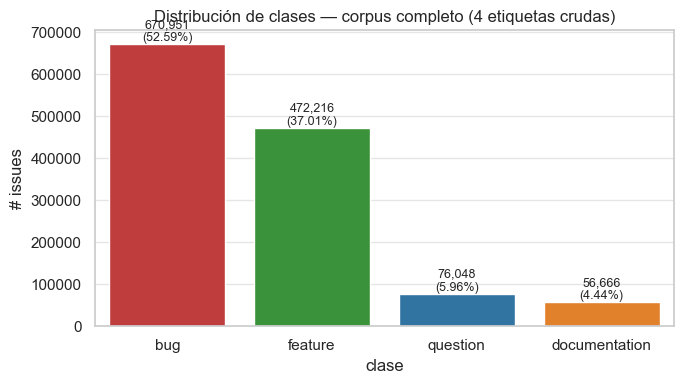

In [4]:
df_clases = pd.DataFrame({
    'clase': list(stats['n_per_class'].keys()),
    'n':     list(stats['n_per_class'].values()),
}).sort_values('n', ascending=False).reset_index(drop=True)
df_clases['pct'] = (df_clases['n'] / stats['n'] * 100).round(2)
df_clases['ratio_vs_min'] = (df_clases['n'] / df_clases['n'].min()).round(2)
display(df_clases)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df_clases, x='clase', y='n', palette=[PALETA[c] for c in df_clases['clase']], ax=ax)
ax.set_title('Distribución de clases — corpus completo (4 etiquetas crudas)')
ax.set_ylabel('# issues')
for i, v in enumerate(df_clases['n']):
    ax.text(i, v, f"{v:,}\n({df_clases['pct'].iloc[i]}%)", ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

> **Decisión (revisión respecto a TDT E2 §8.1):** filtramos `documentation` antes de entrenar y trabajamos sobre 3 clases. El filtrado se aplica en `src/data/splits.py`.

## Apartado 3: Longitud de `title` y `body` por clase

Un body extremadamente largo puede dominar TF-IDF («texto largo → bug» en lugar de la señal lingüística).

In [5]:
def resumen_longitud(arrs_por_clase: dict) -> pd.DataFrame:
    rows = []
    for cls in CLASES_RAW:
        arr = arrs_por_clase.get(cls)
        if arr is None or len(arr) == 0:
            continue
        rows.append({
            'clase': cls, 'n': len(arr),
            'mediana': int(np.median(arr)), 'p75': int(np.percentile(arr, 75)),
            'p95': int(np.percentile(arr, 95)), 'p99': int(np.percentile(arr, 99)),
            'max': int(arr.max()),
        })
    return pd.DataFrame(rows).set_index('clase')

print('Title (caracteres):'); display(resumen_longitud(stats['longs_title']))
print('\nBody (caracteres):');  display(resumen_longitud(stats['longs_body']))

Title (caracteres):


KeyError: 'longs_title'

KeyError: 'longs_title'

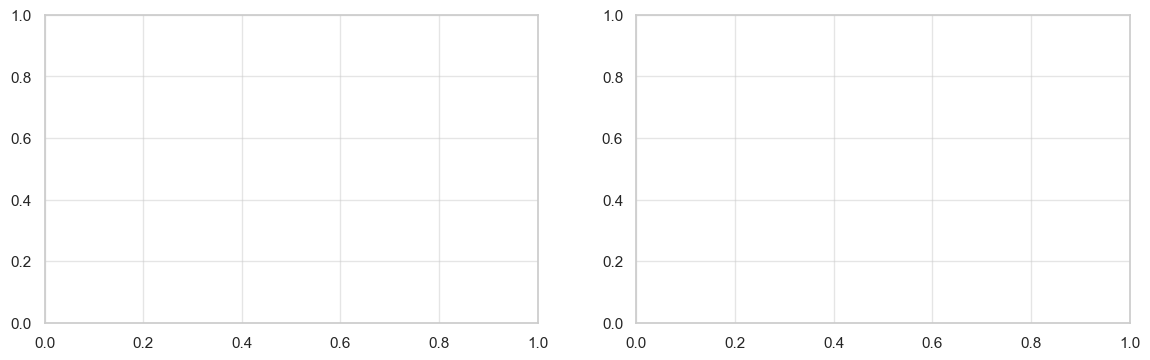

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, ylim, title in [
    (axes[0], 'longs_title', 250,  'Longitud title'),
    (axes[1], 'longs_body',  5000, 'Longitud body (recortado al p99 visual)'),
]:
    data = [stats[key][c] for c in CLASES_RAW if c in stats[key]]
    ax.boxplot(data, labels=[c for c in CLASES_RAW if c in stats[key]], showfliers=False)
    ax.set_title(title); ax.set_ylabel('caracteres'); ax.set_ylim(0, ylim)
plt.tight_layout(); plt.show()

> **Implicación:** truncamos `body` a 5.000 caracteres (`max_text_chars` en `configs/data.yaml`).

## Apartado 4: Fenómenos lingüísticos del TDT §2 — frecuencia por clase

Heatmap normalizado (fracción de issues que dispara cada patrón). Verifica empíricamente que los fenómenos son **discriminativos**.

In [7]:
tabla = []
for nombre in PATRONES:
    hits = stats['patrones_hits'].get(nombre, {})
    fila = {'patron': nombre}
    for cls in CLASES_RAW:
        denom = stats['n_per_class'].get(cls, 0) or 1
        fila[cls] = hits.get(cls, 0) / denom
    tabla.append(fila)
df_pat = pd.DataFrame(tabla).set_index('patron')

fig, ax = plt.subplots(figsize=(7, max(4, 0.4 * len(df_pat))))
sns.heatmap(df_pat, annot=True, fmt='.2f', cmap='YlOrRd', cbar=False, ax=ax)
ax.set_title('Fracción de issues con cada fenómeno (por clase)')
plt.tight_layout(); plt.show()

KeyError: 'patrones_hits'

> **Lectura esperada:**
> - `has_code_block`, `has_traceback`, `has_exception_name` ≫ en `bug`.
> - `has_question_mark`, `has_politeness` ≫ en `question`.
> - `has_version` distribuido (no discriminativo).
> - Confirma TDT §2.1 (pragmático) y §2.2 (hibridación de registros).

## Apartado 5: `author_association`

Señal pragmática complementaria que **no usamos** como feature en C2 (no estará disponible en producción), pero ilustra el perfil de cada clase.

In [ ]:
rows = []
for cls in CLASES_RAW:
    counts = stats['author_per_class'].get(cls, {})
    total = sum(counts.values()) or 1
    for assoc, n in counts.items():
        rows.append({'clase': cls, 'assoc': assoc, 'pct': n / total * 100})
df_aa = pd.DataFrame(rows).pivot(index='assoc', columns='clase', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
df_aa[CLASES_RAW].plot(kind='bar', ax=ax, color=[PALETA[c] for c in CLASES_RAW])
ax.set_title('author_association por clase (%)'); ax.set_ylabel('%')
plt.tight_layout(); plt.show()
df_aa[CLASES_RAW].round(1)

## Apartado 6: Muestra estratificada para análisis léxico

Bernoulli sampling con fracción uniforme, reproducible vía seed, cacheado a parquet.

In [ ]:
TARGET_TOTAL = 50_000
n_total = stats['n']
fraccion = TARGET_TOTAL / n_total

def muestra_bernoulli(csv_path: Path, fraccion: float, seed: int) -> pd.DataFrame:
    r = random.Random(seed)
    rows = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        for row in tqdm(csv.DictReader(f), desc='muestreando', unit=' rows', smoothing=0.05):
            if r.random() < fraccion:
                rows.append(row)
    return pd.DataFrame(rows)

if CACHE_SAMPLE.exists():
    print(f'Cargando caché: {CACHE_SAMPLE}')
    df_sample = pd.read_parquet(CACHE_SAMPLE)
else:
    print(f'Sin caché — muestreo (~{TARGET_TOTAL:,} filas, fracción {fraccion:.4f})…')
    df_sample = muestra_bernoulli(DATA_PATH, fraccion, seed=cfg['seed'])
    df_sample.to_parquet(CACHE_SAMPLE, index=False)

print(f"\nMuestra: {len(df_sample):,} filas")
print(df_sample['labels'].value_counts())

## Apartado 7: Top tokens por clase (TF-IDF rápido)

**Hipótesis previa antes de entrenar:** estos tokens deberían reaparecer como los más influyentes en los coeficientes del SVM (notebook `03`).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

MAX_BODY = 2000
df_sample['texto'] = (df_sample['title'].fillna('') + ' ' +
                      df_sample['body'].fillna('').str[:MAX_BODY])

vec = TfidfVectorizer(lowercase=True, stop_words='english',
                      ngram_range=(1, 1), min_df=20, max_df=0.5, max_features=20_000)
X = vec.fit_transform(df_sample['texto'])
vocab = np.array(vec.get_feature_names_out())
print(f'Vocabulario: {len(vocab):,} términos')

TOPN = 15
tablas = {}
for cls in CLASES_RAW:
    mask = (df_sample['labels'] == cls).values
    if mask.sum() == 0:
        continue
    media = np.asarray(X[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(media)[::-1][:TOPN]
    tablas[cls] = pd.DataFrame({'token': vocab[top_idx], 'tfidf_mean': media[top_idx].round(4)})

for cls, df_top in tablas.items():
    print(f'\n=== {cls} ===')
    print(df_top.to_string(index=False))

## Apartado 8: Duplicados y posibles ruidos de etiquetado

Sanidad: dos issues con el mismo título y etiquetas distintas son ruido (limita la cota superior alcanzable).

In [ ]:
df_sample['title_norm'] = df_sample['title'].fillna('').str.lower().str.strip()
dups = df_sample[df_sample.duplicated('title_norm', keep=False)]
print(f'Filas con título repetido: {len(dups):,} ({len(dups)/len(df_sample)*100:.2f}%)')

if len(dups) > 0:
    conflicto = (dups.groupby('title_norm')['labels'].nunique() > 1).sum()
    print(f'  de los cuales con etiquetas distintas: {conflicto:,}')
    print('\nEjemplos de conflicto:')
    sample_conflicto = (dups.groupby('title_norm')
                            .filter(lambda g: g['labels'].nunique() > 1)
                            .sort_values('title_norm').head(10))
    display(sample_conflicto[['title', 'labels']])

## Conclusiones operativas

Mapa hallazgo → decisión materializada en código:

| Hallazgo                                                         | Decisión en código                                              |
|------------------------------------------------------------------|------------------------------------------------------------------|
| `documentation` minoritaria (~4 %) y fuera del scope del TDT     | Filtrada en `src/data/splits.py` (3 clases)                      |
| Desbalance severo (bug ≫ question)                                | Muestreo balanceado 10k/clase en `src/data/splits.py`            |
| Bodies de hasta 200 KB                                           | `max_text_chars: 5000` en `configs/data.yaml`                    |
| Code blocks / tracebacks dominantes en `bug`                     | `strip_code_blocks → <CODE>` en `src/data/clean.py`              |
| Marcadores pragmáticos (?, please) discriminan `question`        | Preservados (no eliminamos en `clean.py`)                        |
| URLs, emails y handles frecuentes                                | Anonimizados con tokens placeholder en `src/data/anonymize.py`   |
| Posibles duplicados con etiquetas inconsistentes                 | Documentado como cota superior teórica al modelo                 |

Siguiente paso: `02_baseline_majority.ipynb` → `03_tfidf_svm.ipynb`.